# Practical Exercise 2: Data Cleaning
## Airplane Crashes and Fatalities Since 1908

In [ ]:
# 1. Download and upload the Airplane Crashes Dataset from Kaggle.

import pandas as pd

FILENAME = "Airplane_Crashes_and_Fatalities_Since_1908.csv"
# Dataset: https://www.kaggle.com/datasets/saurograndi/airplane-crashes-since-1908

from google.colab import files
print(f"Please upload {FILENAME} (downloaded from the Kaggle link above).")

uploaded = files.upload()
df = pd.read_csv(list(uploaded.keys())[0])

df.head()

Please upload Airplane_Crashes_and_Fatalities_Since_1908.csv (downloaded from the Kaggle link above).


Saving Airplane_Crashes_and_Fatalities_Since_1908.csv to Airplane_Crashes_and_Fatalities_Since_1908.csv


,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary
0,09/17/1908,17:18,"Fort Myer, Virginia",Military - U.S. Army,NaN,Demonstration,Wright Flyer III,NaN,1,2.0,1.0,0.0,"During a demonstration flight, a U.S. Army fly..."
1,07/12/1912,06:30,"AtlantiCity, New Jersey",Military - U.S. Navy,NaN,Test flight,Dirigible,NaN,NaN,5.0,5.0,0.0,First U.S. dirigible Akron exploded just offsh...
2,08/06/1913,NaN,"Victoria, British Columbia, Canada",Private,-,NaN,Curtiss seaplane,NaN,NaN,1.0,1.0,0.0,The first fatal airplane accident in Canada oc...
3,09/09/1913,18:30,Over the North Sea,Military - German Navy,NaN,NaN,Zeppelin L-1 (airship),NaN,NaN,20.0,14.0,0.0,The airship flew into a thunderstorm and encou...
4,10/17/1913,10:30,"Near Johannisthal, Germany",Military - German Navy,NaN,NaN,Zeppelin L-2 (airship),NaN,NaN,30.0,30.0,0.0,Hydrogen gas which was being vented was sucked...


In [ ]:
# 2. Determine the number of rows and columns in the dataset.

n_rows, n_cols = df.shape
print(f"Rows: {n_rows}")
print(f"Columns: {n_cols}")
df.shape

Rows: 5268
Columns: 13


(5268, 13)

In [ ]:
# 3. Display the last 75 rows in the dataset.

df.tail(75)

,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary
5193,03/15/2008,08:15,"Nbagu, Nigeria",Trade Wings Aviation Ltd.,NaN,Lagos - Bebi Air Strip,Beechcraft 1900D,5N-JAH,UE-322,3.0,3.0,0.0,The plane crashed while en route. Wreckage was...
5194,04/03/2008,11:00,"Lawa, Suriname",Blue Wing Airlines,NaN,Paramaribo - Lawa,Antonov An-28,PZ-TSO,1AJ007-17,19.0,19.0,0.0,While attempting to land the crew aborted the ...
5195,04/09/2008,23:27,"Bundeena, Australia",Avtex Air Services,NaN,Sydney - Brisbane,Swearingen SA227AC Metroliner III,VH-OZA,AC-600,1.0,1.0,0.0,The pilot of the mail plane reported some mino...
5196,04/11/2008,22:15,"Chrisinau, Moldova",Kata Transportation,NaN,"Chrisinau, Moldova - Antalya, Turkey - Sudan",Antonov An-32,ST-AZL,3009,8.0,8.0,0.0,Just minutes after the take off the plane trie...
5197,04/15/2008,14:30,"Goma, Congo",Hewa Bora Airways,NaN,Goma - Kisangani - Kinshasa,McDonnell Douglas DC-9-51,9Q-CHN,47731,85.0,0.0,47.0,"While attempting to takeoff, the plane failed ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5263,05/20/2009,06:30,"Near Madiun, Indonesia",Military - Indonesian Air Force,NaN,Jakarta - Maduin,Lockheed C-130 Hercules,A-1325,1982,112.0,98.0,2.0,"While on approach, the military transport cras..."
5264,05/26/2009,NaN,"Near Isiro, DemocratiRepubliCongo",Service Air,NaN,Goma - Isiro,Antonov An-26,9Q-CSA,5005,4.0,4.0,NaN,The cargo plane crashed while on approach to I...
5265,06/01/2009,00:15,"AtlantiOcean, 570 miles northeast of Natal, Br...",Air France,447,Rio de Janeiro - Paris,Airbus A330-203,F-GZCP,660,228.0,228.0,0.0,The Airbus went missing over the AtlantiOcean ...
5266,06/07/2009,08:30,"Near Port Hope Simpson, Newfoundland, Canada",Strait Air,NaN,Lourdes de BlanSablon - Port Hope Simpson,Britten-Norman BN-2A-27 Islander,C-FJJR,424,1.0,1.0,0.0,The air ambulance crashed into hills while att...


In [ ]:
# 4. Missing-data treatment per column, justified.

missing_summary = df.isnull().sum().to_frame(name="Missing count")
missing_summary["Missing %"] = (missing_summary["Missing count"] / len(df) * 100).round(1)
missing_summary

,Missing count,Missing %
Date,0,0.0
Time,2219,42.1
Location,20,0.4
Operator,18,0.3
Flight #,4199,79.7
Route,1707,32.4
Type,27,0.5
Registration,335,6.4
cn/In,1228,23.3
Aboard,22,0.4


In [ ]:
# 5. Create 'fatality_locations' with Date, Location, Aboard, Fatalities.

fatality_locations = df[["Date", "Location", "Aboard", "Fatalities"]].copy()
fatality_locations.head()

,Date,Location,Aboard,Fatalities
0,09/17/1908,"Fort Myer, Virginia",2.0,1.0
1,07/12/1912,"AtlantiCity, New Jersey",5.0,5.0
2,08/06/1913,"Victoria, British Columbia, Canada",1.0,1.0
3,09/09/1913,Over the North Sea,20.0,14.0
4,10/17/1913,"Near Johannisthal, Germany",30.0,30.0


In [ ]:
# 6. Date of the highest recorded fatalities.

max_fatalities_row = fatality_locations.loc[fatality_locations["Fatalities"].idxmax()]
print(f"Highest recorded fatalities: {int(max_fatalities_row['Fatalities'])}")
print(f"Date: {max_fatalities_row['Date']}")
print(f"Location: {max_fatalities_row['Location']}")
max_fatalities_row

Highest recorded fatalities: 583
Date: 03/27/1977
Location: Tenerife, Canary Islands


,2963
Date,03/27/1977
Location,"Tenerife, Canary Islands"
Aboard,644.0
Fatalities,583.0


In [ ]:
# 7. Aboard vs. Fatalities: any zero-fatality crashes?

comparison = fatality_locations.dropna(subset=["Aboard", "Fatalities"]).copy()
comparison["Survivors"] = comparison["Aboard"] - comparison["Fatalities"]
comparison[["Date", "Location", "Aboard", "Fatalities", "Survivors"]].head()

no_fatalities = comparison[comparison["Fatalities"] == 0]
print(f"Crashes with zero fatalities: {len(no_fatalities)}")
no_fatalities[["Date", "Location", "Aboard", "Fatalities"]].head()

Crashes with zero fatalities: 58


,Date,Location,Aboard,Fatalities
108,10/21/1926,English Channel,12.0,0.0
387,03/05/1936,"Near Tengya, China",6.0,0.0
889,10/08/1947,"Near El Paso, Texas",54.0,0.0
897,11/11/1947,"Gallup, New Mexico",25.0,0.0
1265,05/25/1953,"Amsterdam, Netherlands",34.0,0.0


In [ ]:
# 8. Split Location into Region and State/Country.

split_location = fatality_locations["Location"].str.rsplit(",", n=1, expand=True)
fatality_locations["Region"] = split_location[0].str.strip()
fatality_locations["State_Country"] = split_location[1].str.strip()
fatality_locations.head(10)

,Date,Location,Aboard,Fatalities,Region,State_Country
0,09/17/1908,"Fort Myer, Virginia",2.0,1.0,Fort Myer,Virginia
1,07/12/1912,"AtlantiCity, New Jersey",5.0,5.0,AtlantiCity,New Jersey
2,08/06/1913,"Victoria, British Columbia, Canada",1.0,1.0,"Victoria, British Columbia",Canada
3,09/09/1913,Over the North Sea,20.0,14.0,Over the North Sea,None
4,10/17/1913,"Near Johannisthal, Germany",30.0,30.0,Near Johannisthal,Germany
5,03/05/1915,"Tienen, Belgium",41.0,21.0,Tienen,Belgium
6,09/03/1915,"Off Cuxhaven, Germany",19.0,19.0,Off Cuxhaven,Germany
7,07/28/1916,"Near Jambol, Bulgeria",20.0,20.0,Near Jambol,Bulgeria
8,09/24/1916,"Billericay, England",22.0,22.0,Billericay,England
9,10/01/1916,"Potters Bar, England",19.0,19.0,Potters Bar,England


In [ ]:
# 9. Sort by Fatalities descending, take top 100.

top_100_fatalities = fatality_locations.sort_values(by="Fatalities", ascending=False).head(100)
top_100_fatalities.head(10)

,Date,Location,Aboard,Fatalities,Region,State_Country
2963,03/27/1977,"Tenerife, Canary Islands",644.0,583.0,Tenerife,Canary Islands
3568,08/12/1985,"Mt. Osutaka, near Ueno Village, Japan",524.0,520.0,"Mt. Osutaka, near Ueno Village",Japan
4455,11/12/1996,"Near Charkhidadri, India",349.0,349.0,Near Charkhidadri,India
2726,03/03/1974,"Near Ermenonville, France",346.0,346.0,Near Ermenonville,France
3562,06/23/1985,"AtlantiOcean, 110 miles West of Ireland",329.0,329.0,AtlantiOcean,110 miles West of Ireland
3240,08/19/1980,"Near Riyadh, Saudi Arabia",301.0,301.0,Near Riyadh,Saudi Arabia
3775,07/03/1988,"Over the Persian Gulf, near Bandar Abbas, Iran",290.0,290.0,"Over the Persian Gulf, near Bandar Abbas",Iran
4916,02/19/2003,"Near Shahdad, Iran",275.0,275.0,Near Shahdad,Iran
3137,05/25/1979,"Chicago O'Hare, Illinois",271.0,271.0,Chicago O'Hare,Illinois
3436,09/01/1983,"Near Sakhalin Island, Russia",269.0,269.0,Near Sakhalin Island,Russia


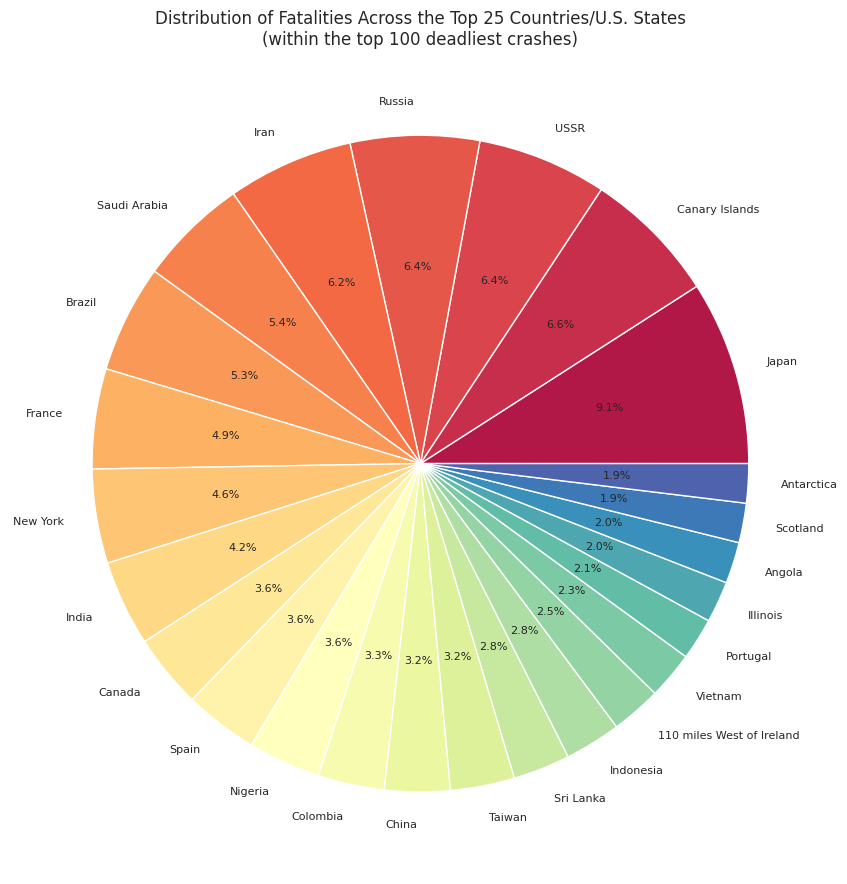

In [ ]:
# 10. Pie chart; top 25 fatalities by country/U.S. State.

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white")

fatalities_by_country = (
    top_100_fatalities.groupby("State_Country")["Fatalities"]
    .sum()
    .sort_values(ascending=False)
)
top_25_countries = fatalities_by_country.head(25)

plt.figure(figsize=(9, 9))
colors = sns.color_palette("Spectral", n_colors=len(top_25_countries))
plt.pie(top_25_countries, labels=top_25_countries.index, autopct="%1.1f%%", colors=colors, textprops={"fontsize": 8})
plt.title("Distribution of Fatalities Across the Top 25 Countries/U.S. States\n(within the top 100 deadliest crashes)")
plt.tight_layout()
plt.show()